<a href="https://colab.research.google.com/github/mikendonga/sentiment_analysis/blob/main/Social_Media_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [7]:
 #Text Preprocessing
 import re
 import string
 from sklearn.model_selection import train_test_split
 from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer


In [8]:

 #models
 from sklearn.naive_bayes import MultinomialNB
 from sklearn.linear_model import LogisticRegression
 from sklearn.svm import SVC
 from sklearn.ensemble import RandomForestClassifier

In [9]:
#evaluation
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import joblib

#ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [10]:
#plot settings
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')


In [11]:
#load dataset
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("kashishparmar02/social-media-sentiments-analysis-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

file_path =os.path.join(path, 'sentimentdataset.csv')
df = pd.read_csv(file_path)
df.head()

Using Colab cache for faster access to the 'social-media-sentiments-analysis-dataset' dataset.
Path to dataset files: /kaggle/input/social-media-sentiments-analysis-dataset
['sentimentdataset.csv']


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [12]:
# dataset info
df.info()

#check for missing values
df.isnull().sum()

#qiuck statistical summary for num columns
df.describe()

#check unique sentiment labels
df['Sentiment'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


array([' Positive  ', ' Negative  ', ' Neutral   ', ' Anger        ',
       ' Fear         ', ' Sadness      ', ' Disgust      ',
       ' Happiness    ', ' Joy          ', ' Love         ',
       ' Amusement    ', ' Enjoyment    ', ' Admiration   ',
       ' Affection    ', ' Awe          ', ' Disappointed ',
       ' Surprise     ', ' Acceptance   ', ' Adoration    ',
       ' Anticipation ', ' Bitter       ', ' Calmness     ',
       ' Confusion    ', ' Excitement   ', ' Kind         ',
       ' Pride        ', ' Shame        ', ' Confusion ', ' Excitement ',
       ' Shame ', ' Elation       ', ' Euphoria      ', ' Contentment   ',
       ' Serenity      ', ' Gratitude     ', ' Hope          ',
       ' Empowerment   ', ' Compassion    ', ' Tenderness    ',
       ' Arousal       ', ' Enthusiasm    ', ' Fulfillment  ',
       ' Reverence     ', ' Compassion', ' Fulfillment   ', ' Reverence ',
       ' Elation   ', ' Despair         ', ' Grief           ',
       ' Loneliness     

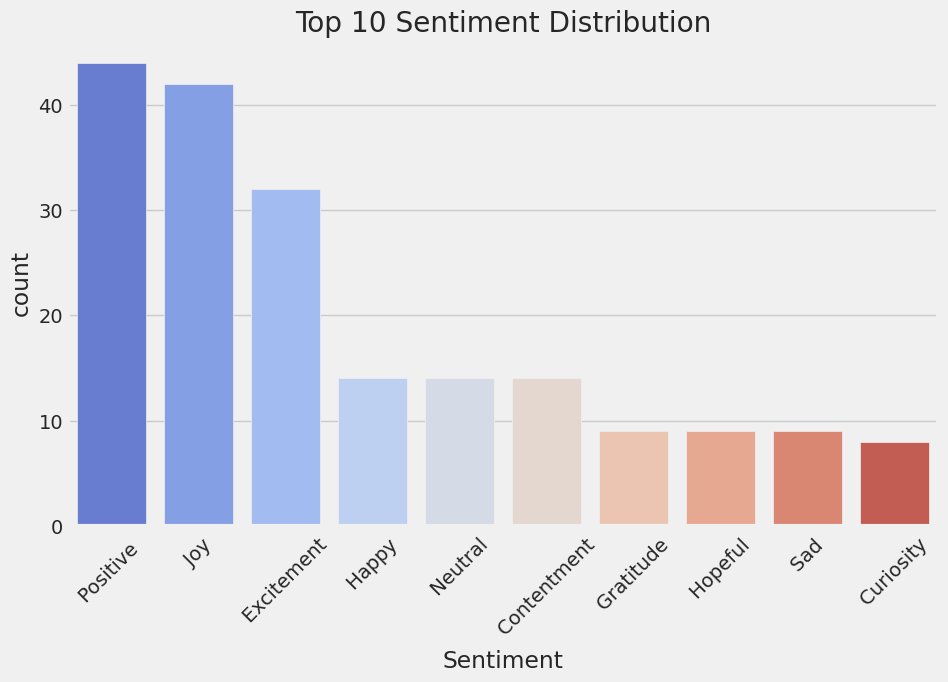

In [13]:
#exploratory data analysis(EDA)

#Get top 10 sentiments by count
top_sentiments = df['Sentiment'].value_counts().head(10).index

#4.1 sentiment distribution
plt.figure(figsize=(10,6))
sns.countplot(x='Sentiment',palette="coolwarm", data=df,order=top_sentiments)
plt.title('Top 10 Sentiment Distribution') # Fixed: added closing quote and corrected '1o' to '10'
plt.xticks(rotation=45) # Fixed: removed extra 'plt.'
plt.show()

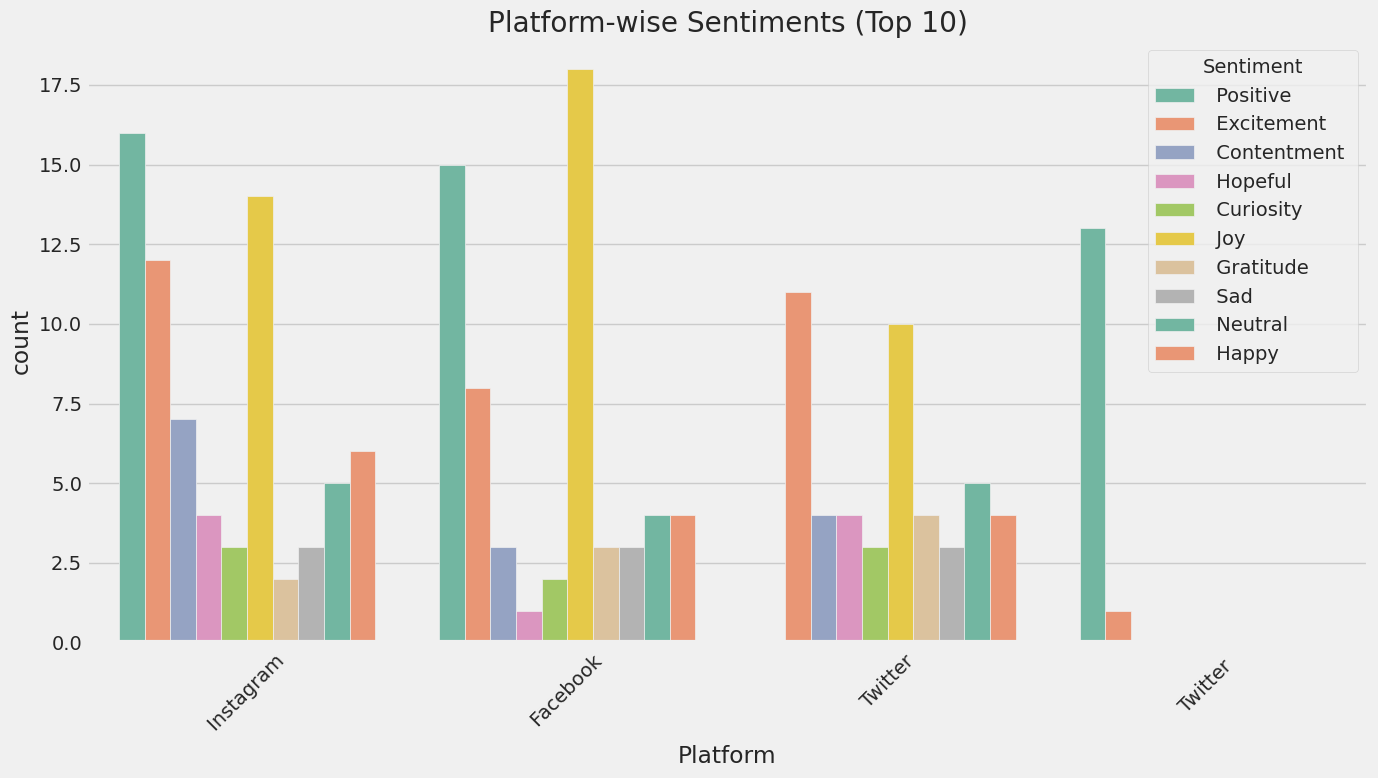

In [14]:
#PlatformWise sentiment distribution
df_top = df[df['Sentiment'].isin(top_sentiments)] # Filter df to include only top 10 sentiments

# Get the order of platforms based on their counts in the filtered dataframe
platform_order = df_top['Platform'].value_counts().index

plt.figure(figsize=(14,8)) # Increased figure size for better visibility
sns.countplot(x='Platform', palette="Set2", data=df_top, order=platform_order, hue="Sentiment")
plt.title("Platform-wise Sentiments (Top 10)") # Corrected title for clarity
plt.xticks(rotation=45) # Increased rotation for x-axis labels if they are long
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

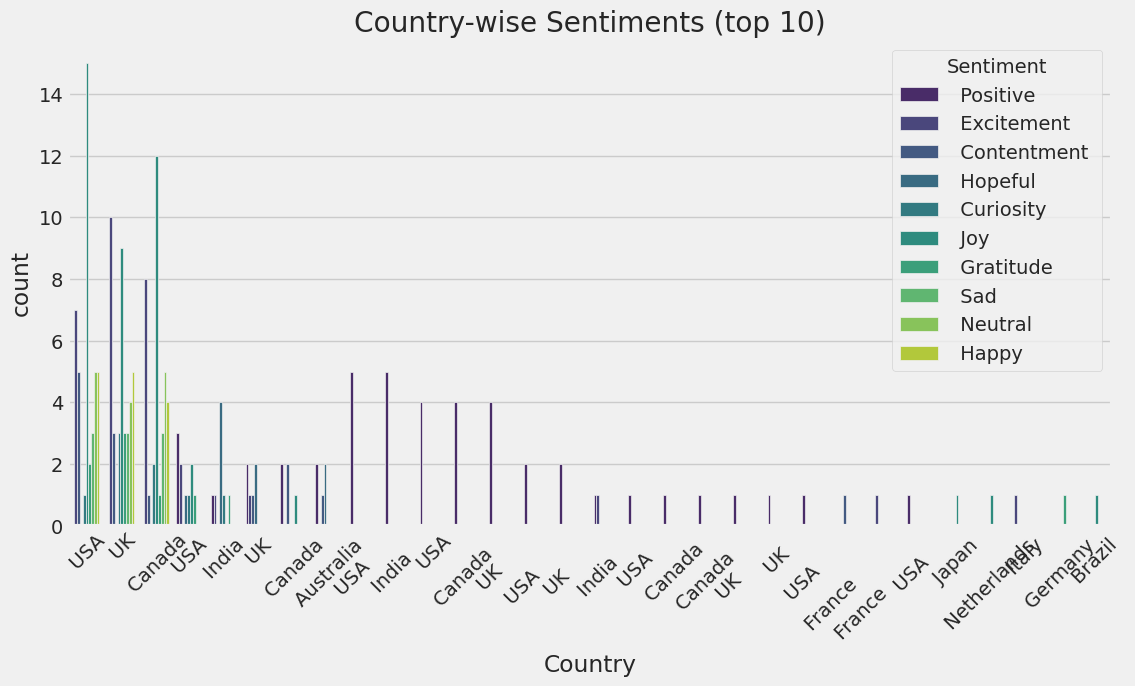

In [15]:
#country-wise sentiments
plt.figure(figsize=(12,6))
country_order_df_top = df_top['Country'].value_counts().index # Get order from df_top
sns.countplot(x='Country', palette="viridis", hue="Sentiment", data=df_top, order=country_order_df_top)
plt.title('Country-wise Sentiments (top 10)')
plt.xticks(rotation=45)
plt.show()

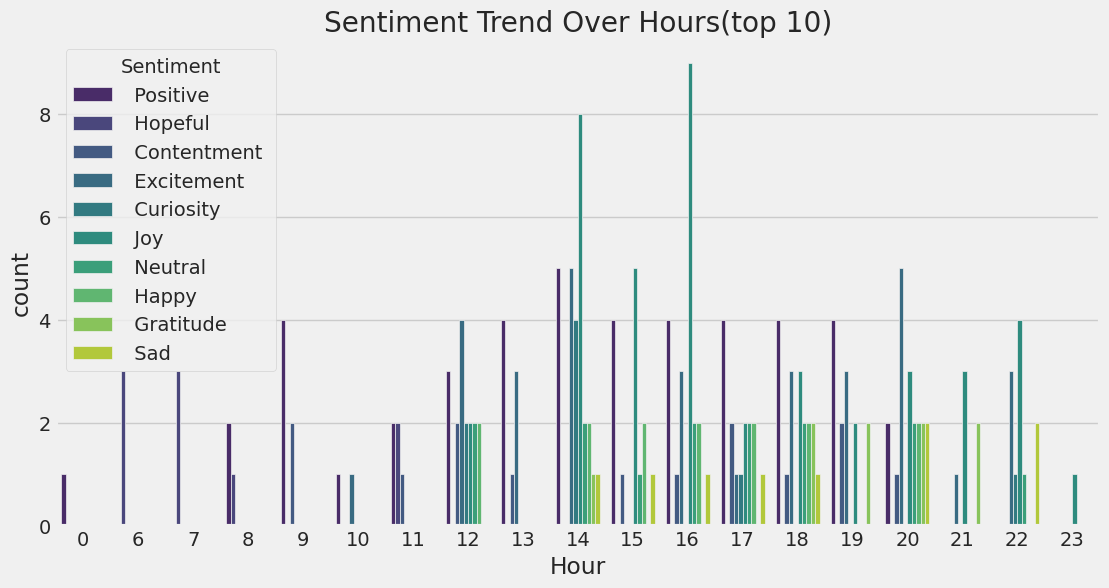

In [16]:
 #sentiment trend over hours
 plt.figure(figsize=(12,6))
 sns.countplot(x='Hour', palette="viridis", hue="Sentiment", data=df_top)
 plt.title('Sentiment Trend Over Hours(top 10)')
 plt.show()


In [17]:
#text cleaning and preprocessing
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text) # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

df["clean_text"] = df["Text"].apply(clean_text) # Corrected indentation and column name
df[["Text", "clean_text"]].head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Text,clean_text
0,Enjoying a beautiful day at the park! ...,enjoying a beautiful day at the park
1,Traffic was terrible this morning. ...,traffic was terrible this morning
2,Just finished an amazing workout! 💪 ...,just finished an amazing workout
3,Excited about the upcoming weekend getaway! ...,excited about the upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying out a new recipe for dinner tonight
5,Feeling grateful for the little things in lif...,feeling grateful for the little things in life
6,Rainy days call for cozy blankets and hot coc...,rainy days call for cozy blankets and hot cocoa
7,The new movie release is a must-watch! ...,the new movie release is a mustwatch
8,Political discussions heating up on the timel...,political discussions heating up on the timeline
9,Missing summer vibes and beach days. ...,missing summer vibes and beach days


In [18]:
import pandas as pd
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import re # Import re for clean_text function
import nltk # Import nltk for stopwords
from nltk.corpus import stopwords
nltk.download("stopwords")

# --- Text cleaning and preprocessing ---
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text) # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

df["clean_text"] = df["Text"].apply(clean_text)

# --- Sentiment Remapping ---
def remap_sentiment(sentiment):
    sentiment = sentiment.strip().lower()
    positive_keywords = [
        'positive', 'joy', 'excitement', 'happy', 'love', 'amusement', 'enjoyment', 'admiration',
        'affection', 'awe', 'acceptance', 'adoration', 'anticipation', 'calmness', 'elation',
        'euphoria', 'contentment', 'serenity', 'gratitude', 'hope', 'empowerment', 'compassion',
        'tenderness', 'arousal', 'enthusiasm', 'fulfillment', 'reverence', 'kind', 'pride',
        'zest', 'hopeful', 'proud', 'grateful', 'empathetic', 'compassionate', 'playful',
        'free-spirited', 'inspired', 'confident', 'thrill', 'harmony', 'creativity', 'radiance',
        'wonder', 'rejuvenation', 'coziness', 'adventure', 'melodic', 'festivejoy',
        'innerjourney', 'freedom', 'dazzle', 'adrenaline', 'artisticburst', 'spark', 'marvel',
        'joyfulreunion', 'satisfaction', 'blessed', 'appreciation', 'confidence', 'accomplishment',
        'wonderment', 'optimism', 'happiness', 'intrigue', 'playfuljoy', 'mindfulness',
        'dreamchaser', 'elegance', 'whimsy', 'mesmerizing', 'winter magic', 'thrilling journey',
        "nature's beauty", 'celestial wonder', 'creative inspiration', 'runway creativity',
        "ocean's freedom", 'emotion', 'energy', 'celebration', 'charm', 'ecstasy', 'hypnotic',
        'connection', 'iconic', 'journey', 'engagement', 'touched', 'triumph', 'heartwarming',
        'solace', 'breakthrough', 'imagination', 'vibrancy', 'culinary adventure', 'relief',
        'mischievous', 'good'
    ]
    negative_keywords = [
        'negative', 'anger', 'fear', 'sadness', 'disgust', 'disappointed', 'bitter', 'shame',
        'despair', 'grief', 'loneliness', 'jealousy', 'resentment', 'frustration', 'boredom',
        'anxiety', 'intimidation', 'helplessness', 'envy', 'regret', 'melancholy', 'fearful',
        'apprehensive', 'overwhelmed', 'devastated', 'frustrated', 'envious', 'dismissive',
        'heartbreak', 'betrayal', 'suffering', 'emotionalstorm', 'isolation', 'disappointment',
        'lostlove', 'exhaustion', 'sorrow', 'darkness', 'desperation', 'ruins', 'desolation',
        'loss', 'heartache', 'solitude', 'suspense', 'obstacle', 'pressure', 'miscalculation',
        'challenge', 'pensive', 'indifference', 'embarrassed', 'sad', 'hate', 'bad',
        'bitterness', 'yearning'
    ]
    neutral_keywords = [
        'neutral', 'confusion', 'contemplation', 'curiosity', 'numbness', 'ambivalence',
        'reflection', 'exploration', 'tranquility', 'grandeur'
    ]

    if sentiment in positive_keywords:
        return 'Positive'
    elif sentiment in negative_keywords:
        return 'Negative'
    elif sentiment in neutral_keywords:
        return 'Neutral'
    else:
        return 'Neutral'

df["Sentiment"] = df["Sentiment"].apply(remap_sentiment)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
# --- Feature Extraction and Train/Test Split
counts = df["Sentiment"].value_counts()
rare_classes = counts[counts < 2].index
df["Sentiment"] = df["Sentiment"].replace(rare_classes, "Neutral")

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)
x = tfidf.fit_transform(df["clean_text"])
y = df["Sentiment"]

# train/test split with stratify
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42)

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC # Import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#model training and comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Linear SVM": LinearSVC() # Corrected to LinearSVC()
}

resultsn={}
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    resultsn[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.6803
Naive Bayes Accuracy: 0.7347
Random Forest Accuracy: 0.6599
Linear SVM Accuracy: 0.7687


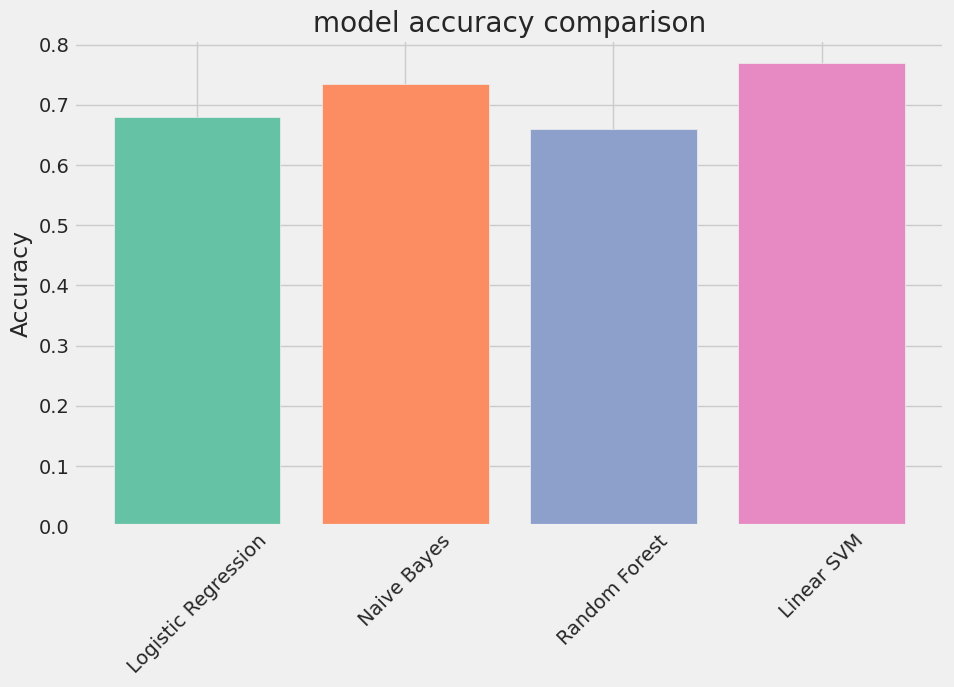

The best performing model is Linear SVM with an accuracy of 0.7687


In [21]:
#visual comparison of model accuracy
import matplotlib.pyplot as plt
import seaborn as sns # Ensure seaborn is imported to use color_palette

if 'resultsn' not in locals() and 'resultsn' not in globals():
    resultsn = {}

plt.figure(figsize=(10,6))
# Using a standard palette like 'Set2'
colors = sns.color_palette("Set2", len(resultsn)) # Generate colors based on the number of models
plt.bar(x=list(resultsn.keys()), height=list(resultsn.values()), color=colors)
plt.title("model accuracy comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

# Ensure resultsn is not empty before attempting to find the best model
if resultsn:
    best_model_name = max(resultsn, key=resultsn.get)
    print(f"The best performing model is {best_model_name} with an accuracy of {resultsn[best_model_name]:.4f}")
else:
    print("No model results available for comparison. Please ensure the model training cell was executed.")

In [22]:
#save the best model and vectorizer
import joblib

joblib.dump(models[best_model_name], 'best_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [23]:
def predict_sentiment(text):
  clean = clean_text(text)
  vec = tfidf.transform([clean])
  pred = models[best_model_name].predict(vec)
  return pred

  #example predictions
  samples = [
      "I love this new feature!"
      "The service was awful and slow."
      "Its okay, not too bad but not great either."
  ]

  for s in samples:
    print(f"Text: {s} Sentiment: {predict_sentiment(s)}")

In [24]:
# Re-initialize and train the Linear SVM model (best performing from previous analysis)
model = LinearSVC()
model.fit(x_train, y_train)

def predict_sentiment(text):
  clean = clean_text(text)
  vector = tfidf.transform([clean])
  prediction = model.predict(vector)
  return prediction[0]

# Example predictions
samples = [
    "I love this new feature!",
    "The service was awful and slow.",
    "Its okay, not too bad not great either.",
    "This movie was absolutely brilliant! I highly recommend it.",
    "I'm so disappointed with the new update, it broke everything.",
    "The weather today is neither good nor bad, just cloudy.",
    "Feeling incredible after a long run.",
    "The flight was delayed again, what a nightmare."
]

for s in samples:
  print(f"text: {s} sentiment: {predict_sentiment(s)}")

text: I love this new feature! sentiment: Positive
text: The service was awful and slow. sentiment: Negative
text: Its okay, not too bad not great either. sentiment: Negative
text: This movie was absolutely brilliant! I highly recommend it. sentiment: Negative
text: I'm so disappointed with the new update, it broke everything. sentiment: Negative
text: The weather today is neither good nor bad, just cloudy. sentiment: Negative
text: Feeling incredible after a long run. sentiment: Negative
text: The flight was delayed again, what a nightmare. sentiment: Negative


Model Accuracy on Test Set: 0.7687

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.71      0.81        38
     Neutral       0.62      0.20      0.30        25
    Positive       0.74      0.96      0.84        84

    accuracy                           0.77       147
   macro avg       0.76      0.62      0.65       147
weighted avg       0.77      0.77      0.74       147


Confusion Matrix:


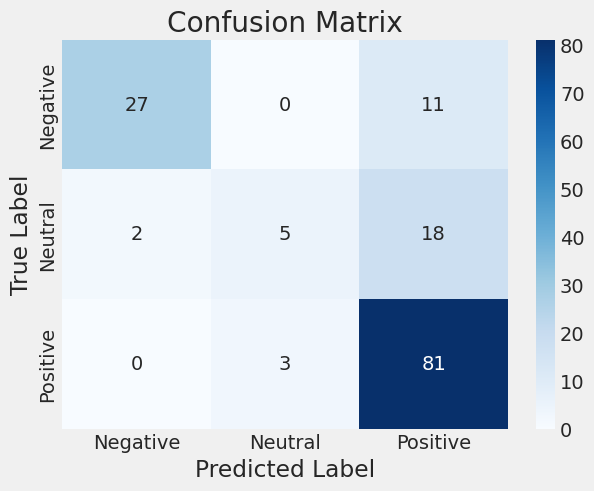

In [25]:
#Calculate model accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()